In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = 'https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv'

try:
    print("Reading data from:", data_path)
    df_ocorrencias = pd.read_csv(data_path, sep=';', encoding='iso-8859-1', decimal=',')
    print(df_ocorrencias.head())

    #Delimitandos as variáveis: cisp, lesao_corp_dolosa, lesao_corp_morte
    df_ocorrencias = df_ocorrencias[['cisp', 'lesao_corp_dolosa', 'lesao_corp_morte']]
    #print(df_ocorrencias.head())

    # Totalizando
    df_total_lesoes = df_ocorrencias.groupby(['cisp']).sum(['lesao_corp_dolosa', 'lesao_corp_morte']).reset_index()
    print(df_total_lesoes.head())
except Exception as e:
    print(f"An error occurred: {e}")

In [10]:
# Correlação

try:
    print('Calculating correlation...')
    #df_corr = df_total_lesoes.corr()
    correlacao = np.corrcoef(df_total_lesoes['lesao_corp_dolosa'], df_total_lesoes['lesao_corp_morte'])[0,1]
    print(f"Correlation: {correlacao:.3f}")
except Exception as e:
    print(f"An error occurred while calculating correlation: {e}")

Calculating correlation...
Correlation: 0.814


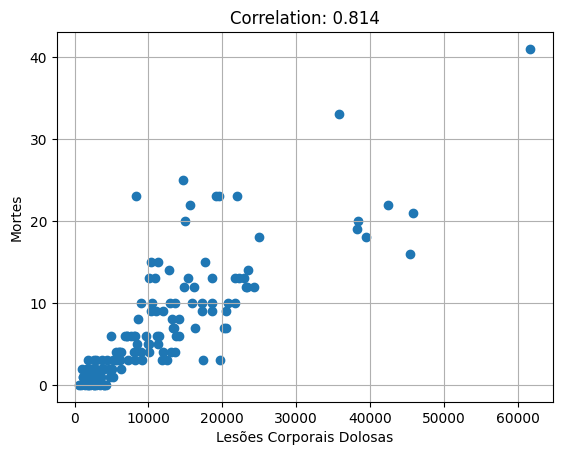

In [14]:
#Visualizando
try:
    # Gráfico de dispersão
    plt.scatter(df_total_lesoes['lesao_corp_dolosa'], df_total_lesoes['lesao_corp_morte'])
    plt.title(f"Correlation: {correlacao:.3f}")
    plt.xlabel('Lesões Corporais Dolosas')
    plt.ylabel('Mortes')
    plt.grid(True)
    plt.show()
except Exception as e:
    print(f"An error occurred while processing the data: {e}")